In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/table1_all_objects_smc_lmc.csv')

In [3]:
td = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/splus_figueiredo_objects_all.csv')

In [4]:
bes = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/be_stars_smc_lmc.csv')

In [5]:
bes['OGLE'] = bes['OGLE'].str.upper()

In [38]:
td

,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,mag_psf_j0515,mag_psf_j0660,mag_psf_j0861,mag_psf_r,mag_psf_u,mag_psf_z,OGLE-II,OGLE-III,OGLE-IV,ura,udec
0,i06MC006500LGX,83.313415,-70.368899,14.704917,14.090043,15.728532,15.607498,15.079253,15.027549,14.511961,14.176908,14.037275,14.224580,16.007727,13.979107,LMC_SC1_108086,LMC170.3.21,LMC516.04.19670,83.31325,-70.36894
1,i06MC0065011W6,83.443651,-70.334890,14.343690,13.966295,15.200883,14.980326,14.560040,14.467279,14.176623,14.012757,13.935305,14.026694,16.038599,13.875994,LMC_SC1_113297,LMC170.3.73425,LMC516.04.19664,83.44342,-70.33486
2,i06MC0065036NG,83.403013,-70.165439,14.487293,13.985323,15.386943,15.252977,14.795618,14.729345,14.310775,14.038442,13.950339,14.075726,15.676666,13.895203,LMC_SC1_124623,LMC170.4.81503,LMC516.12.2,83.40288,-70.16544
3,i06MC006502QKB,83.323564,-70.201760,16.835246,17.029380,16.814699,16.705817,16.684497,16.708429,16.759854,16.685054,17.154289,16.901584,16.941688,17.076527,LMC_SC1_124756,LMC170.4.64358,LMC516.12.274,83.32333,-70.20175
4,i06MC006502XVX,83.311126,-70.188623,16.615934,16.307003,16.671294,16.554218,16.518789,16.513671,16.573671,16.438741,16.116463,16.655441,16.804301,16.008263,LMC_SC1_124784,LMC170.4.64070,LMC516.12.324,83.31079,-70.18892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1646,i06MC0095040OV,16.956891,-72.444309,13.888579,14.283357,13.702030,13.647423,13.712292,13.730037,13.906904,13.918180,14.483866,14.078940,13.775201,14.500265,SMC_SC11_84829,SMC113.1.9040,1,16.95675,-72.44425
1647,i06MC00950503Y,17.030921,-72.325778,14.083792,14.747141,13.849523,13.800396,13.868897,13.899789,14.132376,14.497372,14.928510,14.419316,14.038960,14.953550,SMC_SC11_89099,SMC113.1.31483,SMC725.03.14404,17.03075,-72.32572
1648,i06MC0116091DO,16.591553,-72.778033,15.628201,15.974413,15.463746,15.339416,15.435788,15.458502,15.656265,15.699178,16.164984,15.774030,15.471448,16.171914,SMC_SC11_9050,SMC110.2.15171,SMC726.28.106,16.59129,-72.77789
1649,i06MC0095017JF,16.591485,-72.778000,15.594108,15.967085,15.387776,15.337892,15.436571,15.475411,15.595543,15.686842,16.140736,15.771925,15.453299,16.164510,SMC_SC11_9050,SMC110.2.15171,SMC726.28.106,16.59129,-72.77789


In [45]:
be = pd.merge(td, bes, right_on='OGLE', left_on='OGLE-II', how='inner')

In [106]:
len(be)

930

In [7]:
meus = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all.csv')

In [15]:
be['mag_psf_r'].max()

18.8158381729126

In [ ]:
# faça um histograma para cada coluna de magnitude do dataframe be
be.hist(column=['mag_psf_u', 'mag_psf_g', 'mag_psf_i', 'mag_psf_r', 'mag_psf_z'], bins=20, figsize=(15,10))
plt.suptitle('Histogramas de Magnitudes - Estrelas Be Variáveis')
plt.show() 

In [ ]:
meus['mag_psf_r'].max()

In [ ]:
match = pd.merge(be, meus, left_on='id', right_on='id', how='inner')

In [ ]:
match['mag_psf_r_x'].max()

In [ ]:
match.groupby('main_type')['id'].count()

In [ ]:
match2 = pd.merge(td, meus, left_on='id', right_on='id', how='inner')
len(match2)

# Plotting footprint

In [ ]:
# read s-plus data
all_splus = pd.read_csv('/home/shared/splus_gaia/notebooks/Marina/dr6_list.csv')

#quero filtrar apenas os fields que contém MC no nome
all_splus = all_splus[all_splus['field'].str.contains("MC")]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.colors as colors

from matplotlib import cm
from matplotlib.patches import Polygon
from matplotlib import pyplot as plt

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import BaseEclipticFrame

import copy
import cartopy.crs as ccrs


def plot_splus_field(ra, dec, galactic=False, ax=plt, **kargs):
    
    if ra > 180:
        ra = ra - 360
    ra = -ra
    
    # Calculate corners
    dec0 = dec - 0.7
    dec1 = dec - 0.7
    dec2 = dec + 0.7
    dec3 = dec + 0.7

    ra0 = ra - 0.7/np.cos(dec0*np.pi/180)
    ra1 = ra + 0.7/np.cos(dec1*np.pi/180)
    ra2 = ra + 0.7/np.cos(dec2*np.pi/180)
    ra3 = ra - 0.7/np.cos(dec3*np.pi/180)
    
    ra = np.array([ra0, ra1, ra2, ra3, ra0])
    dec = np.array([dec0, dec1, dec2, dec3, dec0])
    
    ra[ra > 180] = ra[ra > 180] - 360   
    
    dec[dec > 90] = 90
    dec[dec < -90] = -90
    
    ax.fill(ra, dec, **kargs)


def plot_grid(ax=plt, **kwargs):
    # linhas de RA
    for ra in np.arange(-180, 180, 30):
        dera = np.arange(-90, 90, 0.1)
        rara = np.full(len(dera), ra)
        ax.plot(-rara, dera, transform=ccrs.Geodetic(),
                color="#000000", alpha=0.5, linewidth=0.5, zorder=3)

    # linhas de Dec
    for de in np.arange(-90, 90, 30):
        rade = np.arange(-180, 180, 0.1)
        dede = np.full(len(rade), de)
        ax.plot(-rade, dede, transform=ccrs.Geodetic(),
                color="#000000", alpha=0.5, linewidth=0.5, zorder=3)




def plot_points_on_footprint(df, ra_col="ra", dec_col="dec",
                             ax=None, color="red", size=20, zorder=100,
                             transform=ccrs.Geodetic(), **kwargs):

    if ax is None:
        ax = plt.gca()

    ra = df[ra_col].values.copy()
    dec = df[dec_col].values.copy()

    # Converte RA > 180 → RA - 360 (mesmo esquema do footprint)
    ra = np.where(ra > 180, ra - 360, ra)
    # Inverte para mapa celeste
    ra = -ra

    ax.scatter(ra, dec,
               s=size,
               color=color,
               transform=transform,
               zorder=zorder,
               **kwargs)


# ----------------------------
# DEFINIÇÃO LMC / SMC
# ----------------------------

lmc_ra = 15 * (5 + 23/60.)      # ~80.75 deg
lmc_de = -1 * (69 + 45/60.)     # ~ -69.75 deg

smc_ra = 15 * (0 + 52/60.)      # ~13.0 deg
smc_de = -1 * (72 + 48/60.)     # ~ -72.8 deg

lmc_center = SkyCoord(ra=lmc_ra * u.deg, dec=lmc_de * u.deg, frame="icrs")
smc_center = SkyCoord(ra=smc_ra * u.deg, dec=smc_de * u.deg, frame="icrs")

# all_splus deve ter colunas 'ra' e 'dec' dos centros dos campos
fields_coord = SkyCoord(ra=all_splus['ra'].values * u.deg,
                        dec=all_splus['dec'].values * u.deg,
                        frame="icrs")

sep_lmc = fields_coord.separation(lmc_center).deg
sep_smc = fields_coord.separation(smc_center).deg

# raios em graus – ajuste conforme seu gosto
radius_lmc = 12.0
radius_smc = 8.0

mask_mc = (sep_lmc < radius_lmc) | (sep_smc < radius_smc)
splus_mc = all_splus[mask_mc].reset_index(drop=True)

# Se quiser também restringir os PNe à região das Nuvens:
if 'pne_splus' in globals():
    pne_coord = SkyCoord(ra=pne_splus['ra'].values * u.deg,
                         dec=pne_splus['dec'].values * u.deg,
                         frame="icrs")
    sep_lmc_pne = pne_coord.separation(lmc_center).deg
    sep_smc_pne = pne_coord.separation(smc_center).deg
    mask_pne_mc = (sep_lmc_pne < radius_lmc) | (sep_smc_pne < radius_smc)
    pne_mc = pne_splus[mask_pne_mc].reset_index(drop=True)
else:
    pne_mc = None

# ----------------------------
# FIGURA APENAS COM MC
# ----------------------------

plt.figure(figsize=(12, 6))
projection = ccrs.Mollweide()
ax = plt.axes(projection=projection)

# Plot footprint S-PLUS apenas na região das Nuvens
for _, row in splus_mc.iterrows():
    plot_splus_field(row["ra"], row["dec"],
                     ax=ax,
                     transform=ccrs.Geodetic(),
                     color="#666666", alpha=0.25, zorder=50)

# Plot dos objetos (PNe) apenas na região das Nuvens
if pne_mc is not None:
    plot_points_on_footprint(
        pne_mc,
        ra_col="ra",
        dec_col="dec",
        ax=ax,
        color="orange",
        size=2,
        zorder=200,
        alpha=0.8
    )

# Opcional: dar um "zoom" aproximado na região LMC+SMC
# Lembre: o eixo x é -RA; LMC ~ -80°, SMC ~ -13°, Dec ~[-80, -50]
ax.set_extent([-120, 20, -85, -50], crs=ccrs.Geodetic())

plot_grid(ax=ax, color="#000000", alpha=0.7)
plt.tight_layout()

# Pne

In [ ]:
pne = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/central_stars_pne_catalog2024_lmc_smc.csv', delimiter=',', comment='#')

In [ ]:
pne_splus = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/central_stars_pne_splus.csv')

In [ ]:
len(pne_splus['id'].unique())

In [ ]:
match3 = pd.merge(meus, pne_splus, left_on='splus_idr6_id', right_on='id', how='inner', suffixes=('_meus', '_pne'))

In [ ]:
len(match3['id_meus'].unique())

In [ ]:
be

In [ ]:

plt.scatter(be['mag_psf_r'] - be['mag_psf_i'], be['mag_psf_j0660'] - be['mag_psf_r'])

In [ ]:
match3.to_csv('/home/shared/splus_gaia/notebooks/Marina/match_meus_pne_splus.csv', index=False)

In [ ]:
plt.hist(pne_splus['mag_psf_r'], bins=20)
plt.hist(match3['mag_psf_r_meus'], bins=20)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"mag_psf_{b.lower()}_meus" for b in bands]
err_cols = [f"err_mag_psf_{b.lower()}_meus" for b in bands]
has_errors = all(col in match3.columns for col in err_cols)

i = 0
for idx, row in match3.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["Name"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"mag_psf_{b.lower()}" for b in bands]
err_cols = [f"err_mag_psf_{b.lower()}" for b in bands]
has_errors = all(col in pne_splus.columns for col in err_cols)

i = 0
for idx, row in pne_splus.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["Name"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

# bes


In [34]:
meus

,id_x,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,gaia_phot_bp_rp_excess_factor,...,j0660_i,j0660_j0861,u_j0378,j0378_j0410,g_r,j0395_j0410,i_j0861,j0515_r,j0430_g,gaia_source_id
0,b'i06MC007700QSM',37.204273,-70.742390,14.850342,1.106129,1364.524900,0.992964,0,0,1.398709,...,0.668184,1.037410,0.331368,0.997078,1.343954,0.539280,0.369226,1.186033,1.174611,4645248099765187200
1,b'i06MC007700W87',37.665234,-70.546030,7.107466,1.093844,462.059020,0.000001,0,0,1.381371,...,0.606328,0.957330,0.238565,0.982947,1.339872,0.459269,0.351002,1.208238,1.088349,4645344925508069376
2,b'i06MC007700YB8',37.323734,-70.473015,5.347390,1.065020,474.439200,0.998258,0,0,1.280968,...,0.288059,0.456100,0.052822,1.189019,1.194526,0.955651,0.168041,1.141694,0.944715,4645393029141774720
3,b'i06MC007700ZEO',37.238150,-70.431280,5.590915,1.060642,406.684780,0.996487,0,0,1.328209,...,0.435130,0.682548,0.207615,1.104367,1.311902,0.889571,0.247418,1.205523,1.128929,4645394128653396864
4,b'i06MC01390018K',36.038734,-75.364100,0.853479,1.020283,10.123593,0.999961,0,0,1.272933,...,0.100414,0.288274,1.070076,0.922523,1.213757,0.375827,0.187860,1.227909,1.017318,4634203913485331584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43291,b'i06MC00870G60V',81.166885,-70.233320,-0.203989,1.009526,-1.602085,1.000000,0,0,1.104836,...,-0.174308,0.330119,0.520093,NaN,0.907272,NaN,0.504427,0.196211,0.069435,4657931580600225024
43292,b'i06MC00870G62Y',81.347560,-70.234480,0.049941,1.142184,0.353941,0.999984,0,0,1.176908,...,-0.309404,0.251122,NaN,NaN,0.757821,NaN,0.560526,0.161764,0.320998,4657928797633341824
43293,b'i06MC00870G6GB',81.343445,-70.238310,0.050822,1.302804,0.266321,0.999994,0,0,1.349328,...,-0.247217,0.303999,NaN,NaN,0.772853,NaN,0.551216,-0.037936,-0.042875,4657928797633339392
43294,b'i06MC00870G6GT',81.342370,-70.239070,0.171245,1.081208,1.047559,0.999999,0,0,1.281753,...,-0.267445,0.256624,NaN,NaN,0.766688,NaN,0.524069,0.231791,NaN,4657928419676919296


In [59]:
meus['flag_be_star_figueiredo'] = meus['id'].isin(be['id']).astype(int)

In [101]:
bes_simbad = meus[(meus['main_type'] == 'Be*')| (meus['main_type'] == 'Be*_Candidate')]

In [102]:
bes_simbad

,id_x,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,gaia_phot_bp_rp_excess_factor,...,j0660_j0861,u_j0378,j0378_j0410,g_r,j0395_j0410,i_j0861,j0515_r,j0430_g,gaia_source_id,flag_be_star_figueiredo
761,b'i06MC00890DJBL',86.430954,-70.372665,0.031034,0.971566,1.280733,0.000004,0,0,1.159955,...,-0.337369,-0.172154,0.046426,-0.020924,-0.037446,-0.150640,-0.082993,-0.090567,4657182095951763200,1
2550,b'i06MC011502XEG',13.674591,-73.764050,0.032924,1.040628,1.228044,0.999993,0,0,1.280718,...,0.148915,0.201069,0.268478,0.530989,0.132312,0.108723,0.355843,0.091393,4685670751431282560,0
2622,b'i06MC011504UDC',11.721753,-73.557240,0.080202,1.108555,1.449418,0.000078,1,0,1.247704,...,-0.488579,0.087630,0.073913,0.159304,-0.055855,-0.137119,0.111801,-0.074583,4685783691892258560,1
2644,b'i06MC0115054P5',12.909079,-73.541570,0.075947,0.992674,1.548475,0.999998,0,0,1.200538,...,-0.636789,0.178270,0.018206,-0.101836,0.001108,-0.154415,-0.139355,-0.183553,4685863234714469120,1
2683,b'i06MC011505W1H',11.617969,-73.461990,-0.057905,0.956786,-2.819885,0.000050,0,0,1.164702,...,-0.358152,0.049131,0.032824,0.091728,-0.067118,-0.191845,0.019148,-0.146999,4685835025346198912,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32199,b'i06MC003203V7L',81.507730,-67.523186,0.024332,0.908487,0.226910,0.999889,0,0,1.176590,...,-0.685336,0.506215,0.179096,-0.107017,0.063361,-0.096259,-0.044254,-0.144900,4658681481868149888,0
33542,b'i06MC011604Q7V',18.825329,-73.348110,-0.032411,0.920174,-0.249176,0.999999,0,0,1.156098,...,-0.559329,0.122012,0.152972,-0.243122,-0.070584,-0.124577,-0.220259,-0.167214,4686408454997069696,0
33552,b'i06MC01160582J',18.508734,-73.289060,-0.022587,0.940330,-0.136396,0.000050,0,0,0.984648,...,-1.758980,0.491595,-0.699473,0.049036,-0.036770,-0.081640,0.172627,-0.154550,4687160241783259392,0
33568,b'i06MC01160583T',18.448551,-73.310450,-1.107143,1.283727,-3.257301,0.999753,0,0,1.326228,...,-0.926382,0.544321,-0.192910,0.199340,-0.042912,-0.103184,0.314158,0.192708,4687160001297980160,0


In [10]:
match4 = pd.merge(bes_simbad, be, 'left', on = 'id', suffixes=('_simbad', '_be'))

In [50]:
match5 = pd.merge(be, bes_simbad, 'left', on = 'id', suffixes=('_be', '_simb'))

In [51]:
just_andre = match5[match5['main_type'].isna()]

In [52]:
just_andre

,id,ra_be,dec_be,mag_psf_g_be,mag_psf_i_be,mag_psf_j0378_be,mag_psf_j0395_be,mag_psf_j0410_be,mag_psf_j0430_be,mag_psf_j0515_be,...,j0660_i,j0660_j0861,u_j0378,j0378_j0410,g_r,j0395_j0410,i_j0861,j0515_r,j0430_g,gaia_source_id
1,i06MC006502XVX,83.311126,-70.188623,16.615934,16.307003,16.671294,16.554218,16.518789,16.513671,16.573671,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,i06MC0065036AW,83.302655,-70.164758,16.330650,16.802123,16.397505,16.179976,16.132593,16.174196,16.293203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,i06MC00650529X,83.374666,-69.996335,15.215063,15.722150,15.115740,14.997041,15.003347,15.030706,15.188457,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,i06MC006506B3T,83.396303,-69.867926,16.563645,16.656829,16.688472,16.570701,16.506569,16.518425,16.469559,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,i06MC006506RPB,83.388394,-69.835657,18.085931,18.291132,18.294864,18.025239,17.962822,17.947033,18.044921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,i06MC009502UXE,16.982343,-72.585356,15.345069,15.608307,15.153553,15.152773,15.237988,15.231942,15.345255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,i06MC0095040OV,16.956891,-72.444309,13.888579,14.283357,13.702030,13.647423,13.712292,13.730037,13.906904,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
942,i06MC0116091DO,16.591553,-72.778033,15.628201,15.974413,15.463746,15.339416,15.435788,15.458502,15.656265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
943,i06MC0095017JF,16.591485,-72.778000,15.594108,15.967085,15.387776,15.337892,15.436571,15.475411,15.595543,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
len(just_andre)

584

In [ ]:
yes_andre = match4[match4['OGLE'].notna()]

In [21]:
yes_andre.columns.str.contains('meus')

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])

In [14]:
not_andre = match4[match4['OGLE'].isna()]

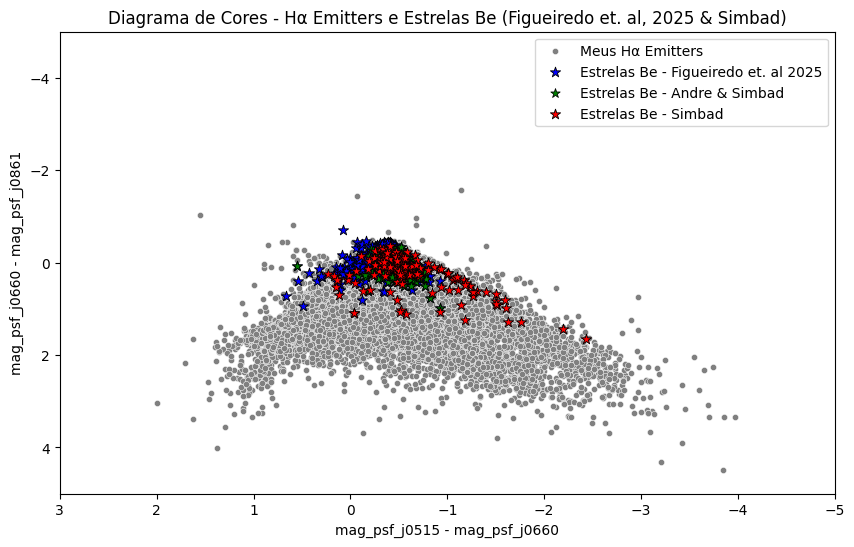

In [28]:
#coloque esse grafico em seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(y=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
                x=meus['mag_psf_j0660'] - meus['mag_psf_j0861'], 
                label='Meus Hα Emitters', color='gray', s=20)
sns.scatterplot(y=be['mag_psf_j0515'] - be['mag_psf_j0660'], 
                x=be['mag_psf_j0660'] - be['mag_psf_j0861'], 
                label='Estrelas Be - Figueiredo et. al 2025', color='blue', s=60, marker = '*', edgecolor='black')
sns.scatterplot(y=yes_andre['mag_psf_j0515_simbad'] - yes_andre['mag_psf_j0660_simbad'], 
                x=yes_andre['mag_psf_j0660_simbad'] - yes_andre['mag_psf_j0861_simbad'], 
                label='Estrelas Be - Andre & Simbad', color='green', marker= '*', s=50, edgecolor='black')

sns.scatterplot(y=not_andre['mag_psf_j0515_simbad'] - not_andre['mag_psf_j0660_simbad'], 
                x=not_andre['mag_psf_j0660_simbad'] - not_andre['mag_psf_j0861_simbad'], 
                label='Estrelas Be - Simbad', color='red', s=60, marker = '*', edgecolor='black')


plt.ylim(5, -5)
plt.xlim(3, -5)

plt.xlabel('mag_psf_j0515 - mag_psf_j0660')
plt.ylabel('mag_psf_j0660 - mag_psf_j0861')
plt.title('Diagrama de Cores - Hα Emitters e Estrelas Be (Figueiredo et. al, 2025 & Simbad)')
plt.legend()

plt.show()


In [121]:
sel = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/studying_diff_objs/selecting_stars_below_be.csv')

In [125]:
selection = sel[sel['flag_be_star_figueiredo'] == 0]
selection2 = sel[sel['flag_be_star_figueiredo'] == 1]


In [128]:
len(selection)

18750

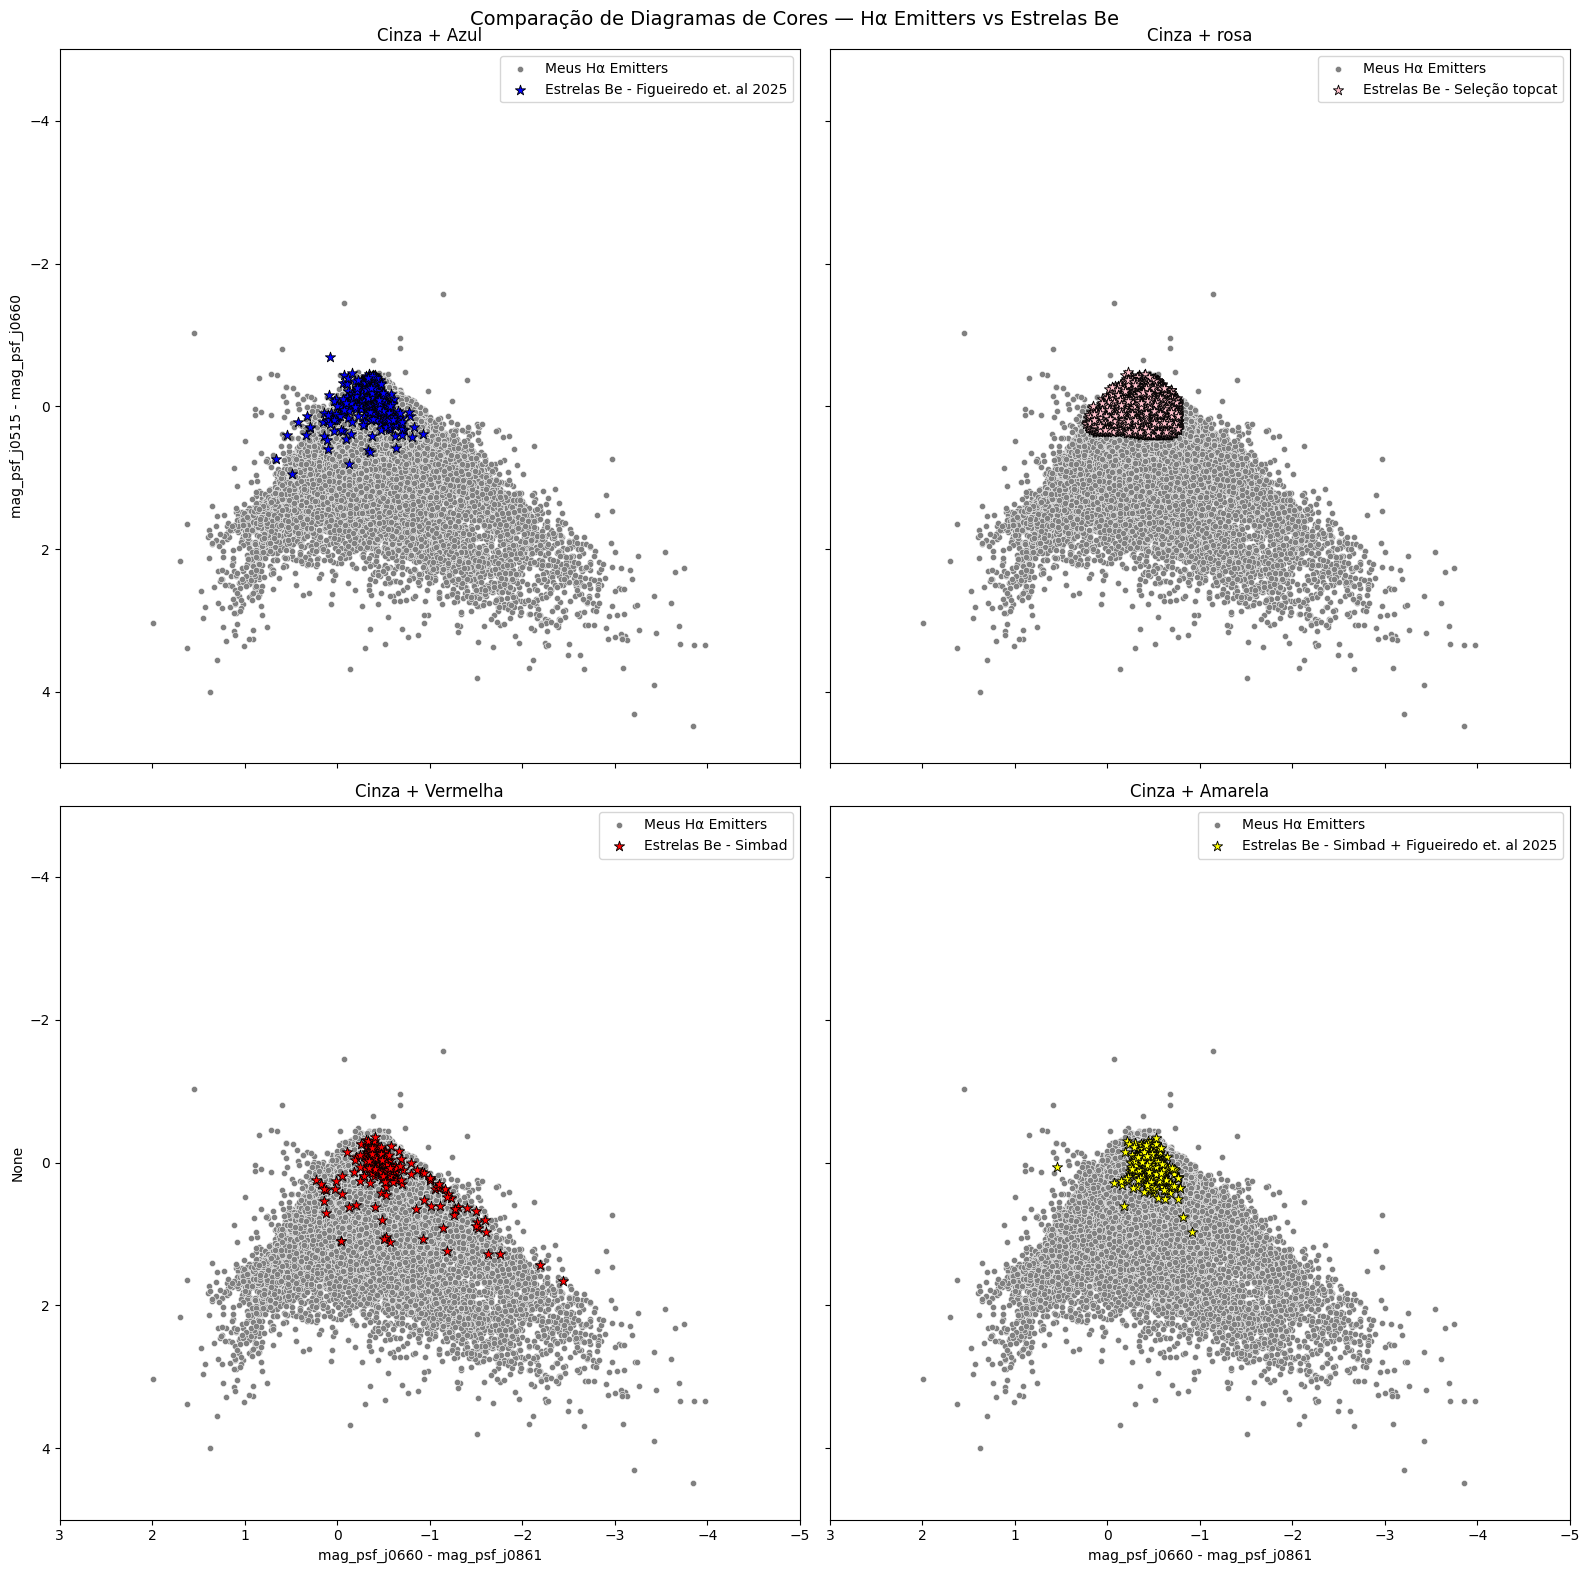

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Limites padronizados
x_min, x_max = 3, -5
y_min, y_max = 5, -5

fig, axes = plt.subplots(2, 2, figsize=(16, 16), sharex=True, sharey=True)

# -------- FIGURA 1 (Cinza + Azul) ----------
sns.scatterplot(
    ax=axes[0][0],
    y=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
    x=meus['mag_psf_j0660'] - meus['mag_psf_j0861'], 
    label='Meus Hα Emitters', color='gray', s=20
)

sns.scatterplot(
    ax=axes[0][0],
    y=just_andre['mag_psf_j0515_be'] - just_andre['mag_psf_j0660_be'], 
    x=just_andre['mag_psf_j0660_be'] - just_andre['mag_psf_j0861_be'], 
    label='Estrelas Be - Figueiredo et. al 2025', color='blue', s=60,
    marker='*', edgecolor='black'
)

axes[0][0].set_title('Cinza + Azul')
axes[0][0].set_xlim(x_min, x_max)
axes[0][0].set_ylim(y_min, y_max)
axes[0][0].set_xlabel('mag_psf_j0660 - mag_psf_j0861')
axes[0][0].set_ylabel('mag_psf_j0515 - mag_psf_j0660')
axes[0][0].legend()

# -------- FIGURA 2 (Cinza + Vermelha) ----------
sns.scatterplot(
    ax=axes[1][0],
    y=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
    x=meus['mag_psf_j0660'] - meus['mag_psf_j0861'], 
    label='Meus Hα Emitters', color='gray', s=20
)

sns.scatterplot(
    ax=axes[1][0],
    y=not_andre['mag_psf_j0515_simbad'] - not_andre['mag_psf_j0660_simbad'], 
    x=not_andre['mag_psf_j0660_simbad'] - not_andre['mag_psf_j0861_simbad'], 
    label='Estrelas Be - Simbad', color='red', s=60,
    marker='*', edgecolor='black'
)

axes[1][0].set_title('Cinza + Vermelha')
axes[1][0].set_xlim(x_min, x_max)
axes[1][0].set_ylim(y_min, y_max)
axes[1][0].set_xlabel('mag_psf_j0660 - mag_psf_j0861')
axes[1][0].legend()

#--------- Figura 3 ----------

sns.scatterplot(
    ax=axes[1][1],
    y=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
    x=meus['mag_psf_j0660'] - meus['mag_psf_j0861'], 
    label='Meus Hα Emitters', color='gray', s=20
)

sns.scatterplot(
    ax=axes[1][1],
    y=yes_andre['mag_psf_j0515_simbad'] - yes_andre['mag_psf_j0660_simbad'], 
    x=yes_andre['mag_psf_j0660_simbad'] - yes_andre['mag_psf_j0861_simbad'], 
    label='Estrelas Be - Simbad + Figueiredo et. al 2025', color='yellow', s=60,
    marker='*', edgecolor='black'
)

axes[1][1].set_title('Cinza + Amarela')
axes[1][1].set_xlim(x_min, x_max)
axes[1][1].set_ylim(y_min, y_max)
axes[1][1].set_xlabel('mag_psf_j0660 - mag_psf_j0861')
axes[1][1].legend()

#--------- Figura 4 ----------

sns.scatterplot(
    ax=axes[0][1],
    y=meus['mag_psf_j0515'] - meus['mag_psf_j0660'], 
    x=meus['mag_psf_j0660'] - meus['mag_psf_j0861'], 
    label='Meus Hα Emitters', color='gray', s=20
)

sns.scatterplot(
    ax=axes[0][1],
    y=selection['mag_psf_j0515'] - selection['mag_psf_j0660'], 
    x=selection['mag_psf_j0660'] - selection['mag_psf_j0861'], 
    label='Estrelas Be - Seleção topcat', color='pink', s=60,
    marker='*', edgecolor='black'
)

axes[0][1].set_title('Cinza + rosa')
axes[0][1].set_xlim(x_min, x_max)
axes[0][1].set_ylim(y_min, y_max)
axes[0][1].set_xlabel('mag_psf_j0660 - mag_psf_j0861')
axes[0][1].legend()

fig.suptitle('Comparação de Diagramas de Cores — Hα Emitters vs Estrelas Be', fontsize=14)
plt.tight_layout()
plt.show()

In [132]:
selection['mag_psf_r'].min()

13.001324

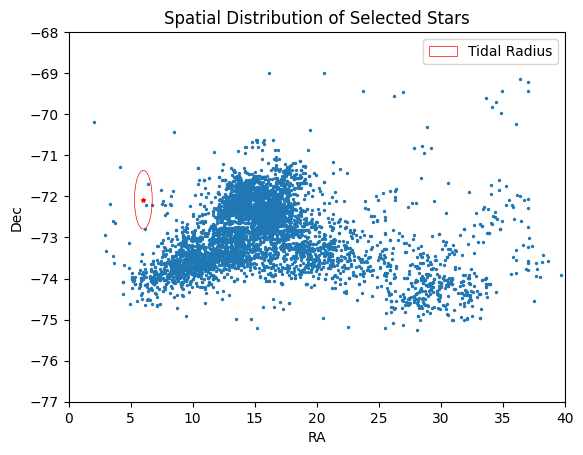

In [150]:
plt.scatter(selection['ra'], selection['dec'], s=2)
plt.xlabel('RA')
plt.ylabel('Dec')
plt.title('Spatial Distribution of Selected Stars')

# RA e DEC do centro (em graus)
ra0 = 6.023625
dec0 = -72.081278

# raios em arcmin
core_radius = 0.36
half_light_radius = 3.17
tidal_radius = 42.9

# converter arcmin → graus
arcmin_to_deg = 1/60
core_deg = core_radius * arcmin_to_deg
half_deg = half_light_radius * arcmin_to_deg
tidal_deg = tidal_radius * arcmin_to_deg

ax = plt.gca()

# adicionar círculos
cir3 = Circle((ra0, dec0), tidal_deg, edgecolor='red', fill=False, linewidth=0.5, label='Tidal Radius')

ax.add_patch(cir3)
plt.xlim(0, 40)
plt.ylim(-77, -68)
plt.scatter(ra0, dec0, s=8, marker='*', color='red')  # marca o centro
plt.legend()
plt.show()


# spectra

In [62]:
import adss

In [64]:
client = adss.ADSSClient(
    base_url="https://ai-scope.cbpf.br", 
    username="marinaiza", 
    password="Mari1407*"
)

In [98]:
res = client.query(
   f"select top 100 * from public.ztf_dr22 where cone(ra,dec,{just_andre['ra_be'].iloc[1]},{just_andre['dec_be'].iloc[1]},2)",
    mode = "astroql"    
)

In [99]:
res

QueryResult(query=Query(id='sync_query', query_text='select top 100 * from public.ztf_dr22 where cone(ra,dec,83.30265529678962,-70.16475844617916,2)', status='completed', created_at=Timestamp('2025-12-09 11:50:26.184814'), mode='astroql', user_id=None, completed_at=Timestamp('2025-12-09 11:50:26.184841'), result_url=None, error=None, execution_time_ms=3055, row_count=0, position_in_queue=None, expires_at=None, query_metadata=None), data=Empty DataFrame
Columns: [id, filterid, fieldid, rcid, ra, dec, nepochs, hmjd, mag, magerr, clrcoeff, catflags]
Index: [], execution_time_ms=3055, row_count=0, column_count=0)

In [96]:
import matplotlib.pyplot as plt

index = 7
mjd_array = res.data.iloc[index]['hmjd']
mag_array = res.data.iloc[index]['mag']
mag_err_array = res.data.iloc[index]['magerr']

# change the size of the points 
plt.errorbar(mjd_array, mag_array, yerr=mag_err_array, fmt='o', color='blue', ecolor='lightgray', capsize=2, markersize=1)
plt.gca().invert_yaxis()
plt.xlabel('MJD')
plt.ylabel('Magnitude')
plt.title('Light Curve from ZTF DR22')
plt.show()

IndexError: single positional indexer is out-of-bounds